In [3]:

# PART 2: FINANCIAL REVENUE AND CASH FLOW PLANNING
# Author: Shushma Sadanand

# Business Question: what is the 'Projected turnover for upcoming month'?
# Solution: Weekly revenue aggregation with ARIMA forecasting

# Application: Capital expenditure planning, supplier payments, marketing budgets


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Time series specific libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
# Styling
plt.style.use('ggplot')
sns.set_palette("Set2")

print("_"*80)
print("\nPART 2: FINANCIAL REVENUE & CASH FLOW PLANNING")
print("_"*80)

print("\n Business Question: What is the projected turnover for the upcoming month?")
print(" Solution: Weekly revenue forecasting using ARIMA")
print(" Application: Capital expenditure planning, supplier payments, marketing budgets\n")

________________________________________________________________________________

PART 2: FINANCIAL REVENUE & CASH FLOW PLANNING
________________________________________________________________________________

 Business Question: What is the projected turnover for the upcoming month?
 Solution: Weekly revenue forecasting using ARIMA
 Application: Capital expenditure planning, supplier payments, marketing budgets



# Basic Data Analysis

In [10]:
print("-"*60)
print("STEP 1: DATA LOADING AND BASIC ANALYSIS")
print("-"*60)

------------------------------------------------------------
STEP 1: DATA LOADING AND BASIC ANALYSIS
------------------------------------------------------------


In [12]:
# Load the dataset
df = pd.read_csv('car_sales_data.csv')
print(f"\n Dataset loaded: {df.shape[0]} transactions-(rows), {df.shape[1]} columns")

# Data overview
print("\n First 5 rows:")
print(df.head())

print("\n Data types:")
print(df.dtypes)


 Dataset loaded: 23906 transactions-(rows), 16 columns

 First 5 rows:
         Car_id      Date Customer Name Gender  Annual Income  \
0  C_CND_000001  1/2/2022     Geraldine   Male          13500   
1  C_CND_000002  1/2/2022           Gia   Male        1480000   
2  C_CND_000003  1/2/2022        Gianna   Male        1035000   
3  C_CND_000004  1/2/2022       Giselle   Male          13500   
4  C_CND_000005  1/2/2022         Grace   Male        1465000   

                           Dealer_Name   Company       Model  \
0  Buddy Storbeck's Diesel Service Inc      Ford  Expedition   
1                     C & M Motors Inc     Dodge     Durango   
2                          Capitol KIA  Cadillac    Eldorado   
3               Chrysler of Tri-Cities    Toyota      Celica   
4                    Chrysler Plymouth     Acura          TL   

                      Engine Transmission       Color  Price ($)  Dealer_No   \
0  DoubleÂ Overhead Camshaft         Auto       Black      26000  06457-

# Data Cleaning and Preparation

In [19]:
print("\n" + "-"*60)
print("STEP 2: DATA CLEANING AND PREPARATION")
print("-"*60)


------------------------------------------------------------
STEP 2: DATA CLEANING AND PREPARATION
------------------------------------------------------------


In [14]:
print(" Missing values:")
print(df.isnull().sum())

 Missing values:
Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64


In [15]:
# Drop rows with any missing values (specifically targeting 'Customer Name' here)
df_cleaned = df.dropna(subset=['Customer Name'])

print(f"Number of rows after dropping missing values: {df_cleaned.shape[0]}")

# Verify that there are no more missing values in 'Customer Name'
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

Number of rows after dropping missing values: 23905

Missing values after cleaning:
Car_id           0
Date             0
Customer Name    0
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64


In [16]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Clean Price column (remove $ and commas)
df['Price ($)'] = df['Price ($)'].astype(str).str.replace('$', '', regex=False)
df['Price ($)'] = df['Price ($)'].str.replace(',', '', regex=False)
df['Price ($)'] = pd.to_numeric(df['Price ($)'], errors='coerce')

# Remove invalid prices
invalid_prices = df['Price ($)'].isna().sum()
if invalid_prices > 0:
    print(f" Found {invalid_prices} rows with invalid prices - removing them")
    df = df.dropna(subset=['Price ($)'])
else:
    print(" No rows with invalid prices found.")

 No rows with invalid prices found.


In [17]:
# Sort by date
df = df.sort_values('Date')

print(f"\n Data cleaned: {len(df)} valid transactions")
print(f" Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f" Price range: ${df['Price ($)'].min():,.0f} to ${df['Price ($)'].max():,.0f}")
print(f" Companies: {df['Company'].nunique()}")
print(f" Regions: {df['Dealer_Region'].nunique()}")


 Data cleaned: 23906 valid transactions
 Date range: 2022-01-02 to 2023-12-31
 Price range: $1,200 to $85,800
 Companies: 30
 Regions: 7


# Aggregate sales volume and revenue on a daily basis

In [18]:
print("\n" + "-"*60)
print("STEP 3: DAILY AGGREGATION - SALES VOLUME & REVENUE")
print("-"*60)


------------------------------------------------------------
STEP 3: DAILY AGGREGATION - SALES VOLUME & REVENUE
------------------------------------------------------------


In [20]:
# Daily sales volume (count)
daily_volume = df.resample('D', on='Date').size()

# Daily revenue (sum)
daily_revenue = df.resample('D', on='Date')['Price ($)'].sum()

# Combine into one dataframe
daily_data = pd.DataFrame({
    'sales_volume': daily_volume,
    'total_revenue': daily_revenue
})

In [21]:
# Fill missing dates with 0 (no sales)
date_range = pd.date_range(start=daily_data.index.min(), end=daily_data.index.max(), freq='D')
daily_data = daily_data.reindex(date_range, fill_value=0)

print(f"\n Daily aggregates created:")
print(f"   • Total days: {len(daily_data)}")
print(f"   • Date range: {daily_data.index.min().date()} to {daily_data.index.max().date()}")
print(f"   • Avg daily sales: {daily_data['sales_volume'].mean():.2f} cars")
print(f"   • Avg daily revenue: ${daily_data['total_revenue'].mean():,.2f}")
print(f"   • Total revenue: ${daily_data['total_revenue'].sum():,.2f}")
print(f"   • Total cars sold: {daily_data['sales_volume'].sum():,.0f}")


 Daily aggregates created:
   • Total days: 729
   • Date range: 2022-01-02 to 2023-12-31
   • Avg daily sales: 32.79 cars
   • Avg daily revenue: $921,159.76
   • Total revenue: $671,525,465.00
   • Total cars sold: 23,906


# Examine patterns in sales volume and revenue

In [22]:
print("\n" + "-"*60)
print("STEP 4: PATTERN ANALYSIS - SALES VOLUME & REVENUE")
print("-"*60)


------------------------------------------------------------
STEP 4: PATTERN ANALYSIS - SALES VOLUME & REVENUE
------------------------------------------------------------


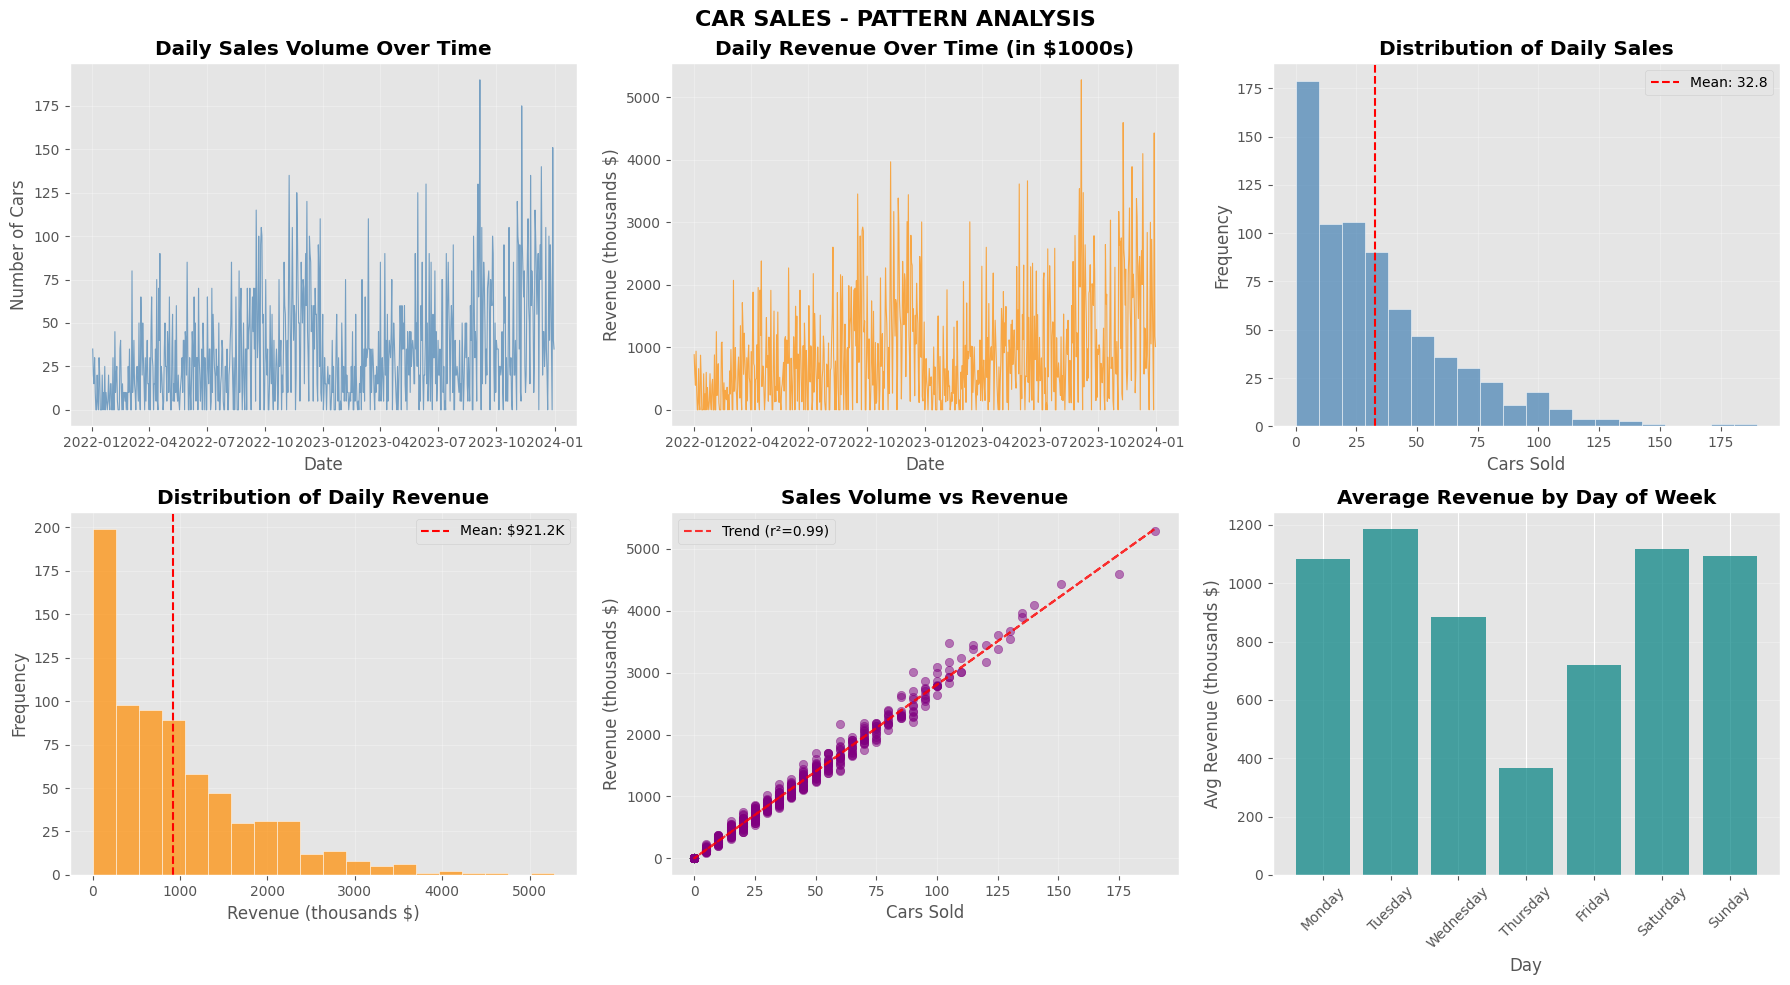


 Pattern analysis visualizations saved to 'part2_pattern_analysis.png'


In [25]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CAR SALES - PATTERN ANALYSIS', fontsize=16, fontweight='bold')

# 1. Daily sales volume over time
axes[0, 0].plot(daily_data.index, daily_data['sales_volume'], color='steelblue', alpha=0.7, linewidth=0.8)
axes[0, 0].set_title('Daily Sales Volume Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Cars')
axes[0, 0].grid(True, alpha=0.3)

# 2. Daily revenue over time
axes[0, 1].plot(daily_data.index, daily_data['total_revenue']/1000, color='darkorange', alpha=0.7, linewidth=0.8)
axes[0, 1].set_title('Daily Revenue Over Time (in $1000s)', fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Revenue (thousands $)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sales volume distribution
axes[0, 2].hist(daily_data['sales_volume'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 2].axvline(daily_data['sales_volume'].mean(), color='red', linestyle='--',
                   label=f"Mean: {daily_data['sales_volume'].mean():.1f}")
axes[0, 2].set_title('Distribution of Daily Sales', fontweight='bold')
axes[0, 2].set_xlabel('Cars Sold')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Revenue distribution
axes[1, 0].hist(daily_data['total_revenue']/1000, bins=20, color='darkorange', edgecolor='white', alpha=0.7)
axes[1, 0].axvline(daily_data['total_revenue'].mean()/1000, color='red', linestyle='--',
                   label=f"Mean: ${daily_data['total_revenue'].mean()/1000:.1f}K")
axes[1, 0].set_title('Distribution of Daily Revenue', fontweight='bold')
axes[1, 0].set_xlabel('Revenue (thousands $)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Sales vs Revenue scatter
axes[1, 1].scatter(daily_data['sales_volume'], daily_data['total_revenue']/1000,
                   alpha=0.5, color='purple')
z = np.polyfit(daily_data['sales_volume'], daily_data['total_revenue']/1000, 1)
p = np.poly1d(z)
axes[1, 1].plot(daily_data['sales_volume'], p(daily_data['sales_volume']),
                "r--", alpha=0.8, label=f"Trend (r²={np.corrcoef(daily_data['sales_volume'], daily_data['total_revenue'])[0,1]**2:.2f})")
axes[1, 1].set_title('Sales Volume vs Revenue', fontweight='bold')
axes[1, 1].set_xlabel('Cars Sold')
axes[1, 1].set_ylabel('Revenue (thousands $)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Day of week analysis
daily_data['day_of_week'] = daily_data.index.day_name()
daily_data['day_num'] = daily_data.index.dayofweek
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = daily_data.groupby('day_of_week')['total_revenue'].mean() / 1000
dow_avg = dow_avg.reindex(day_order)

axes[1, 2].bar(day_order, dow_avg.values, color='teal', alpha=0.7)
axes[1, 2].set_title('Average Revenue by Day of Week', fontweight='bold')
axes[1, 2].set_xlabel('Day')
axes[1, 2].set_ylabel('Avg Revenue (thousands $)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('part2_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Pattern analysis visualizations saved to 'part2_pattern_analysis.png'")



In [28]:
# ============================================
# BUSINESS INSIGHTS FROM PATTERNS
# ============================================

print("\n BUSINESS INSIGHTS FROM PATTERNS:")
print("_"*40)
print(f"\n   • The business generates an average of ${daily_data['total_revenue'].mean()/1000:.1f}K daily revenue")
print(f"   • Revenue is {'strongly' if np.corrcoef(daily_data['sales_volume'], daily_data['total_revenue'])[0,1] > 0.8 else 'moderately'} correlated with sales volume")
print(f"   • Best revenue day: {dow_avg.idxmax()} (${dow_avg.max():.1f}K average)")
print(f"   • There are {(daily_data['total_revenue'] == 0).sum()} days with zero revenue")


 BUSINESS INSIGHTS FROM PATTERNS:
________________________________________

   • The business generates an average of $921.2K daily revenue
   • Revenue is strongly correlated with sales volume
   • Best revenue day: Tuesday ($1185.3K average)
   • There are 117 days with zero revenue


# Experiment with different time windows (7, 30, 90 days)

In [29]:
print("\n" + "-"*60)
print("STEP 5: MULTIPLE TIME WINDOWS ANALYSIS (7, 30, 90 DAYS)")
print("-"*60)


------------------------------------------------------------
STEP 5: MULTIPLE TIME WINDOWS ANALYSIS (7, 30, 90 DAYS)
------------------------------------------------------------


In [30]:
# Calculate rolling averages
windows = [7, 30, 90]
window_labels = ['7-Day', '30-Day', '90-Day']
colors = ['green', 'orange', 'red']

# Create rolling window dataframe
rolling_data = daily_data[['sales_volume', 'total_revenue']].copy()

for window in windows:
    rolling_data[f'revenue_ma_{window}'] = daily_data['total_revenue'].rolling(window=window, min_periods=1).mean()
    rolling_data[f'revenue_ma_{window}_K'] = rolling_data[f'revenue_ma_{window}'] / 1000


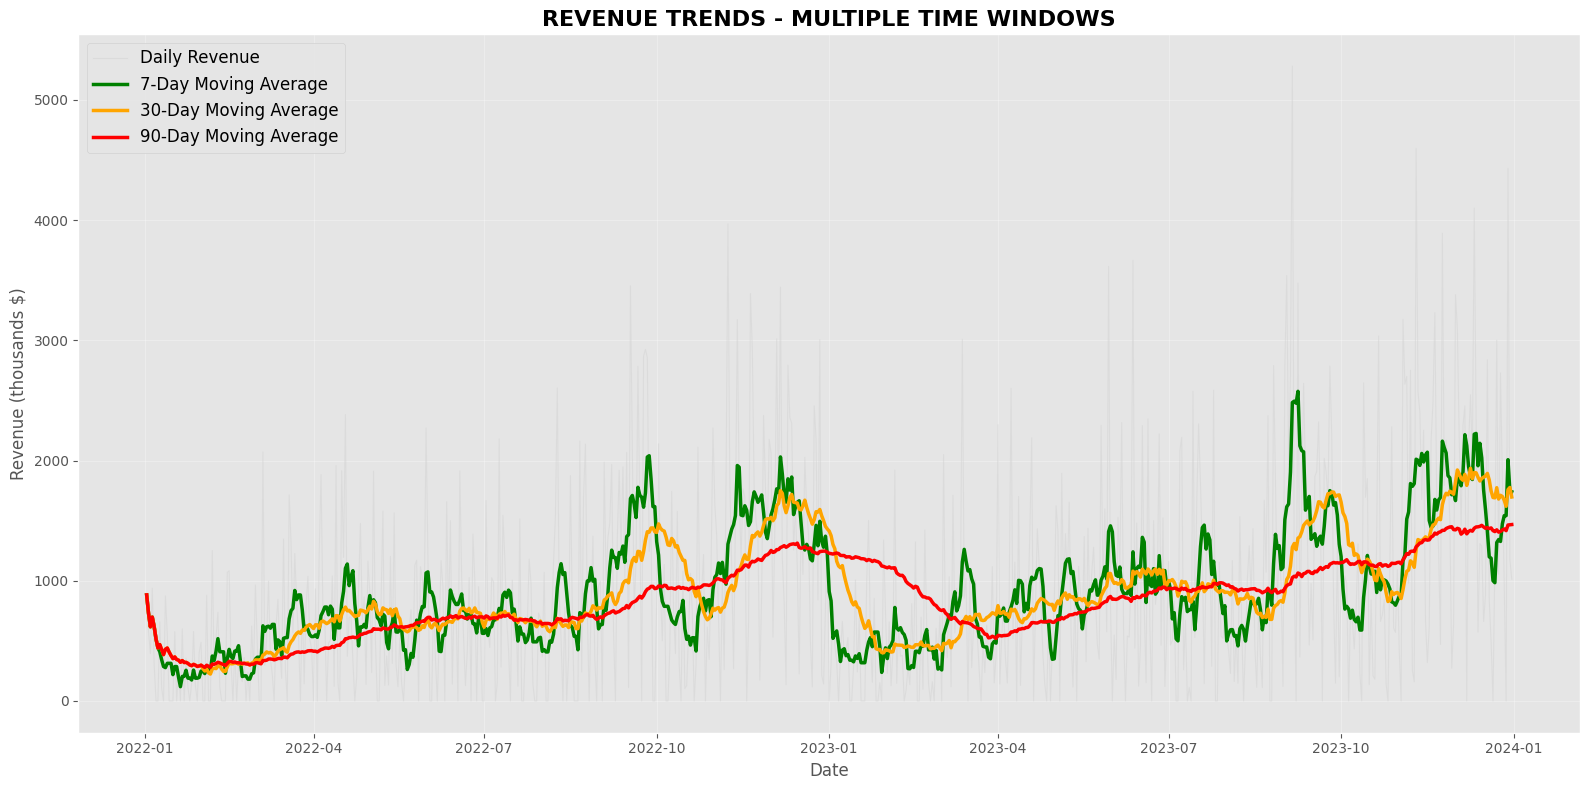


 Multiple windows visualization saved to 'part2_multiple_windows.png'


In [31]:
# Visualize revenue with different windows
plt.figure(figsize=(16, 8))

# Plot daily revenue (background)
plt.plot(rolling_data.index, rolling_data['total_revenue']/1000,
         color='lightgray', alpha=0.5, label='Daily Revenue', linewidth=0.8)

# Plot rolling averages
for i, window in enumerate(windows):
    plt.plot(rolling_data.index, rolling_data[f'revenue_ma_{window}']/1000,
             color=colors[i], linewidth=2.5, label=f'{window_labels[i]} Moving Average')

plt.title('REVENUE TRENDS - MULTIPLE TIME WINDOWS', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (thousands $)')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_multiple_windows.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Multiple windows visualization saved to 'part2_multiple_windows.png'")

#  Identify business insights from different windows

In [32]:
print("\n" + "-"*60)
print("STEP 6: BUSINESS INSIGHTS FROM DIFFERENT TIME WINDOWS")
print("-"*60)


------------------------------------------------------------
STEP 6: BUSINESS INSIGHTS FROM DIFFERENT TIME WINDOWS
------------------------------------------------------------


In [38]:
# Latest values
latest_revenue = daily_data['total_revenue'].iloc[-1]
latest_date = daily_data.index[-1].strftime('%Y-%m-%d')

print(f"\n CURRENT STATUS (as of {latest_date}):")
print(f"   • Latest daily revenue: ${latest_revenue:,.0f}")

print("\n TREND COMPARISON:")
print("-"*40)

for i, window in enumerate(windows):
    current_avg = rolling_data[f'revenue_ma_{window}'].iloc[-1]
    pct_diff = ((latest_revenue - current_avg) / current_avg) * 100 if current_avg > 0 else 0

    # Determine trend direction
    # Compare with value from 2 windows ago to see trend
    if len(rolling_data) > window*2:
        past_avg = rolling_data[f'revenue_ma_{window}'].iloc[-window]
        trend_direction = "INCREASING" if current_avg > past_avg else "DECREASING"
        trend_pct = ((current_avg - past_avg) / past_avg) * 100
    else:
        trend_direction = "INSUFFICIENT DATA"
        trend_pct = 0

    print(f"\n   {window_labels[i]} Window:")
    print(f"      • Average revenue: ${current_avg:,.0f}")
    print(f"      • Latest vs average: {pct_diff:+.1f}%")
    print(f"      • Trend: {trend_direction} ({trend_pct:+.1f}% over last {window} days)")




 CURRENT STATUS (as of 2023-12-31):
   • Latest daily revenue: $1,012,406

 TREND COMPARISON:
----------------------------------------

   7-Day Window:
      • Average revenue: $1,740,412
      • Latest vs average: -41.8%
      • Trend: INCREASING (+31.2% over last 7 days)

   30-Day Window:
      • Average revenue: $1,696,746
      • Latest vs average: -40.3%
      • Trend: DECREASING (-11.7% over last 30 days)

   90-Day Window:
      • Average revenue: $1,467,327
      • Latest vs average: -31.0%
      • Trend: INCREASING (+26.1% over last 90 days)


In [39]:
# Find peak periods
print("\n KEY PATTERN DETECTION:")
print("-"*40)

for window in windows:
    revenue_ma = rolling_data[f'revenue_ma_{window}']

    peak_idx = revenue_ma.idxmax()
    peak_value = revenue_ma.max()
    trough_idx = revenue_ma.idxmin()
    trough_value = revenue_ma.min()

    print(f"\n   {window_labels[i]} Window:")
    print(f"      • Peak period: {peak_idx.strftime('%Y-%m-%d')} (${peak_value:,.0f})")
    print(f"      • Low period: {trough_idx.strftime('%Y-%m-%d')} (${trough_value:,.0f})")
    print(f"      • Range: ${peak_value - trough_value:,.0f} ({((peak_value - trough_value)/trough_value*100):.0f}% variation)")


 KEY PATTERN DETECTION:
----------------------------------------

   90-Day Window:
      • Peak period: 2023-09-08 ($2,575,388)
      • Low period: 2022-01-20 ($118,821)
      • Range: $2,456,567 (2067% variation)

   90-Day Window:
      • Peak period: 2023-12-09 ($1,935,312)
      • Low period: 2022-02-05 ($223,942)
      • Range: $1,711,370 (764% variation)

   90-Day Window:
      • Peak period: 2023-12-31 ($1,467,327)
      • Low period: 2022-02-02 ($279,122)
      • Range: $1,188,204 (426% variation)


# Task
Fix the second `for` loop in the 'KEY PATTERN DETECTION' section to correctly use `enumerate(windows)` so that `window_labels[i]` accurately reflects the current window being processed, and then confirm that the output now correctly displays labels for 7-Day, 30-Day, and 90-Day windows.

## Fix Key Pattern Detection Loop

### Subtask:
Modify the second `for` loop in the 'KEY PATTERN DETECTION' section to correctly use `enumerate(windows)` so that `window_labels[i]` accurately reflects the current window being processed.


**Reasoning**:
The subtask requires modifying the second `for` loop in the 'KEY PATTERN DETECTION' section to correctly use `enumerate(windows)` so that `window_labels[i]` accurately reflects the current window being processed. The current code has a bug where `i` is not updated within the loop, leading to the same `window_labels[i]` being printed for all iterations. I will provide the corrected code block for the `izJ8xr4OfIFq` cell.



In [43]:
print("\n KEY PATTERN DETECTION:")
print("-"*40)

for i, window in enumerate(windows):
    revenue_ma = rolling_data[f'revenue_ma_{window}']

    peak_idx = revenue_ma.idxmax()
    peak_value = revenue_ma.max()
    trough_idx = revenue_ma.idxmin()
    trough_value = revenue_ma.min()

    print(f"\n   {window_labels[i]} Window:")
    print(f"      • Peak period: {peak_idx.strftime('%Y-%m-%d')} (${peak_value:,.0f})")
    print(f"      • Low period: {trough_idx.strftime('%Y-%m-%d')} (${trough_value:,.0f})")
    print(f"      • Range: ${peak_value - trough_value:,.0f} ({((peak_value - trough_value)/trough_value*100):.0f}% variation)")


 KEY PATTERN DETECTION:
----------------------------------------

   7-Day Window:
      • Peak period: 2023-09-08 ($2,575,388)
      • Low period: 2022-01-20 ($118,821)
      • Range: $2,456,567 (2067% variation)

   30-Day Window:
      • Peak period: 2023-12-09 ($1,935,312)
      • Low period: 2022-02-05 ($223,942)
      • Range: $1,711,370 (764% variation)

   90-Day Window:
      • Peak period: 2023-12-31 ($1,467,327)
      • Low period: 2022-02-02 ($279,122)
      • Range: $1,188,204 (426% variation)


# WEEKLY AGGREGATION FOR ARIMA FORECASTING


In [44]:
print("\n" + "-"*60)
print("STEP 7: WEEKLY AGGREGATION FOR FORECASTING")
print("-"*60)


------------------------------------------------------------
STEP 7: WEEKLY AGGREGATION FOR FORECASTING
------------------------------------------------------------


In [46]:
# Aggregate to weekly level (for forecasting)
weekly_revenue = df.resample('W', on='Date')['Price ($)'].sum().reset_index()
weekly_revenue.columns = ['Week_Ending', 'Weekly_Revenue']
weekly_revenue.set_index('Week_Ending', inplace=True)

print(f"\n Weekly aggregates created:")
print(f"   • Total weeks: {len(weekly_revenue)}")
print(f"   • Date range: {weekly_revenue.index.min().date()} to {weekly_revenue.index.max().date()}")
print(f"   • Avg weekly revenue: ${weekly_revenue['Weekly_Revenue'].mean():,.0f}")
print(f"   • Min weekly revenue: ${weekly_revenue['Weekly_Revenue'].min():,.0f}")
print(f"   • Max weekly revenue: ${weekly_revenue['Weekly_Revenue'].max():,.0f}")




 Weekly aggregates created:
   • Total weeks: 105
   • Date range: 2022-01-02 to 2023-12-31
   • Avg weekly revenue: $6,395,481
   • Min weekly revenue: $882,250
   • Max weekly revenue: $14,574,682


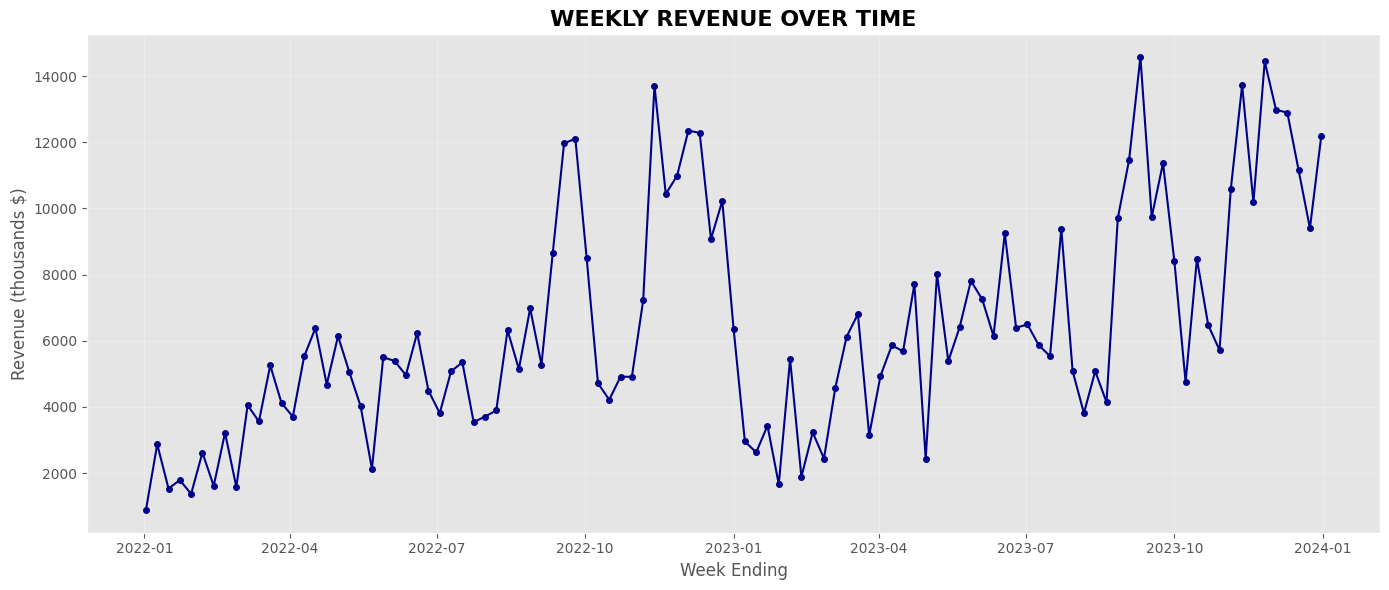

In [47]:
# Visualize weekly revenue
plt.figure(figsize=(14, 6))
plt.plot(weekly_revenue.index, weekly_revenue['Weekly_Revenue']/1000,
         marker='o', markersize=4, color='darkblue', linewidth=1.5)
plt.title('WEEKLY REVENUE OVER TIME', fontsize=16, fontweight='bold')
plt.xlabel('Week Ending')
plt.ylabel('Revenue (thousands $)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_weekly_revenue.png', dpi=150)
plt.show()

# STATIONARITY TESTING

In [48]:
print("\n" + "-"*60)
print("STEP 8: STATIONARITY TESTING FOR ARIMA")
print("-"*60)


------------------------------------------------------------
STEP 8: STATIONARITY TESTING FOR ARIMA
------------------------------------------------------------


In [51]:
def check_stationarity(series, title):
    """Perform ADF test and return result"""
    result = adfuller(series.dropna())

    print(f"\n {title}")
    print(f"   Test Statistic: {result[0]:.4f}")
    print(f"   p-value: {result[1]:.4f}")
    print('   Critical Values:')
    for key, value in result[4].items():
        print(f'      {key}: {value:.4f}')

    if result[1] <= 0.05:
        print("    STATIONARY - Ready for ARIMA")
        return True
    else:
        print("    NON-STATIONARY - Transformations needed")
        return False

# Test weekly revenue
is_stationary = check_stationarity(weekly_revenue['Weekly_Revenue'], 'Weekly Revenue')

# If non-stationary, apply transformations
transformations = {'log': False, 'diff': 0}

if not is_stationary:
    print("\n Applying transformations to achieve stationarity...")

    # Try log transformation
    log_revenue = np.log(weekly_revenue['Weekly_Revenue'])
    print("\nAfter Log Transformation:")
    is_log_stationary = check_stationarity(log_revenue, 'Log Weekly Revenue')

    if is_log_stationary:
        model_series = log_revenue
        transformations['log'] = True
    else:
        # Try first difference
        diff_revenue = weekly_revenue['Weekly_Revenue'].diff().dropna()
        print("\nAfter First Difference:")
        is_diff_stationary = check_stationarity(diff_revenue, 'Differenced Weekly Revenue')

        if is_diff_stationary:
            model_series = diff_revenue
            transformations['diff'] = 1
        else:
            # Try log + difference
            log_diff = log_revenue.diff().dropna()
            print("\nAfter Log + Difference:")
            is_log_diff_stationary = check_stationarity(log_diff, 'Log-Differenced Revenue')

            if is_log_diff_stationary:
                model_series = log_diff
                transformations['log'] = True
                transformations['diff'] = 1
            else:
                print(" Series still non-stationary - will proceed with caution")
                model_series = weekly_revenue['Weekly_Revenue']
else:
    model_series = weekly_revenue['Weekly_Revenue']


 Weekly Revenue
   Test Statistic: -2.8679
   p-value: 0.0492
   Critical Values:
      1%: -3.4955
      5%: -2.8900
      10%: -2.5820
    STATIONARY - Ready for ARIMA


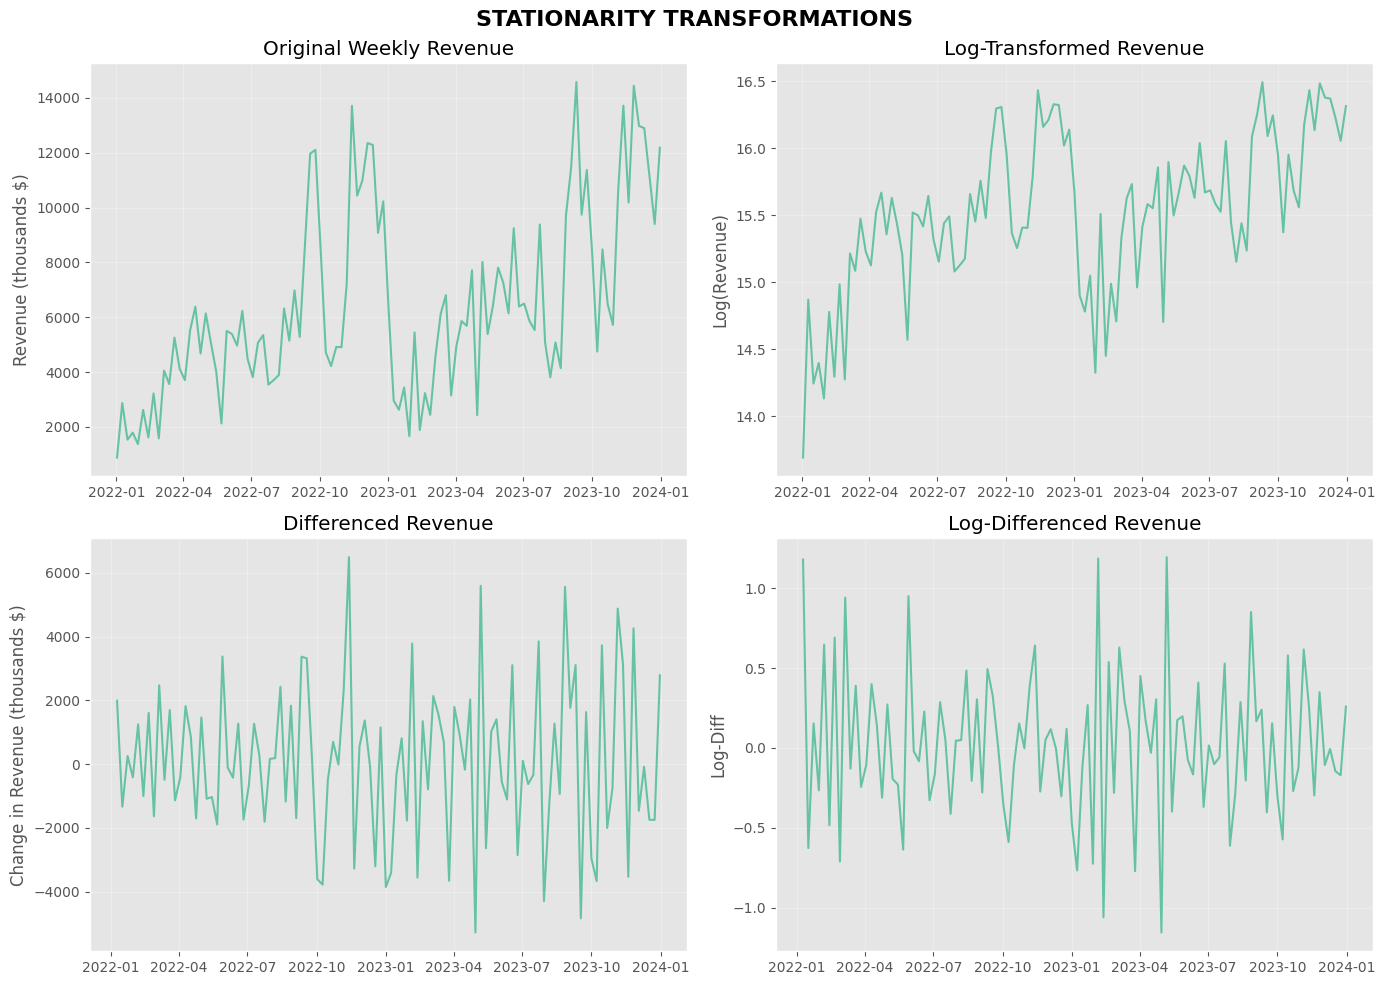

In [50]:
# Visualize transformations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('STATIONARITY TRANSFORMATIONS', fontsize=16, fontweight='bold')

axes[0, 0].plot(weekly_revenue.index, weekly_revenue['Weekly_Revenue']/1000)
axes[0, 0].set_title('Original Weekly Revenue')
axes[0, 0].set_ylabel('Revenue (thousands $)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(weekly_revenue.index, np.log(weekly_revenue['Weekly_Revenue']))
axes[0, 1].set_title('Log-Transformed Revenue')
axes[0, 1].set_ylabel('Log(Revenue)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(weekly_revenue.index[1:], weekly_revenue['Weekly_Revenue'].diff().dropna()/1000)
axes[1, 0].set_title('Differenced Revenue')
axes[1, 0].set_ylabel('Change in Revenue (thousands $)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(weekly_revenue.index[1:], np.log(weekly_revenue['Weekly_Revenue']).diff().dropna())
axes[1, 1].set_title('Log-Differenced Revenue')
axes[1, 1].set_ylabel('Log-Diff')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part2_stationarity.png', dpi=150)
plt.show()


# ACF/PACF ANALYSIS FOR ARIMA ORDER SELECTION

In [53]:
print("\n" + "-"*60)
print("STEP 9: ACF/PACF ANALYSIS FOR ARIMA ORDER SELECTION")
print("-"*60)


------------------------------------------------------------
STEP 9: ACF/PACF ANALYSIS FOR ARIMA ORDER SELECTION
------------------------------------------------------------


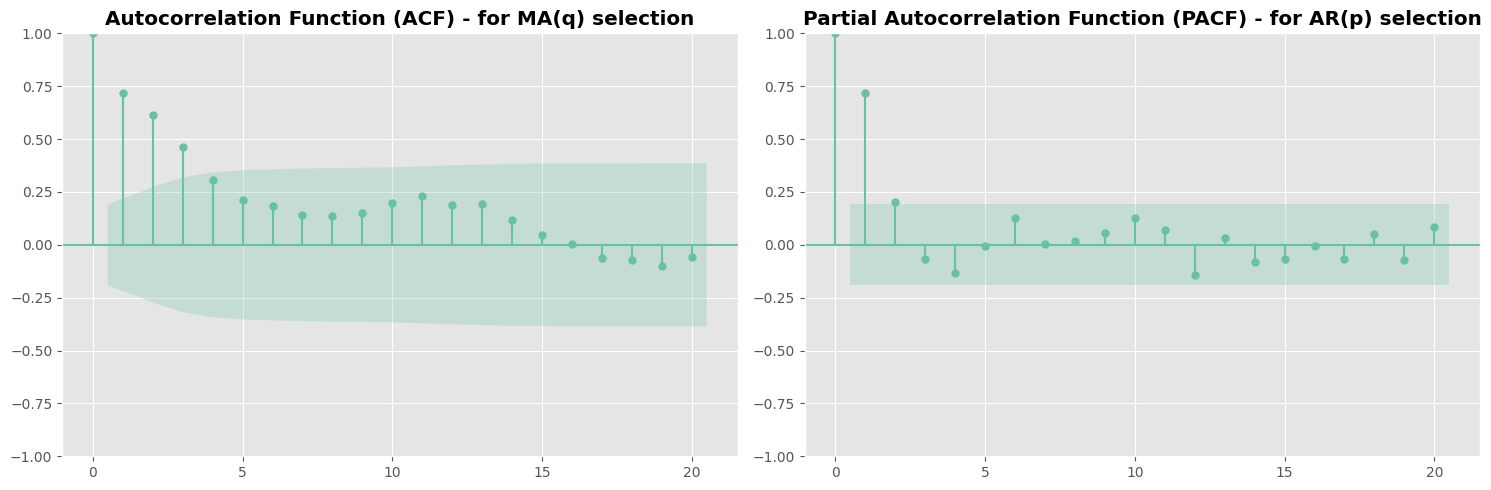


 ACF/PACF Interpretation Guide:
   • If PACF cuts off after lag p → AR(p)
   • If ACF cuts off after lag q → MA(q)
   • If both decay slowly → need more differencing
   • Spikes at lag 4 suggest monthly patterns

 Selected ARIMA order: (1, 0, 1)


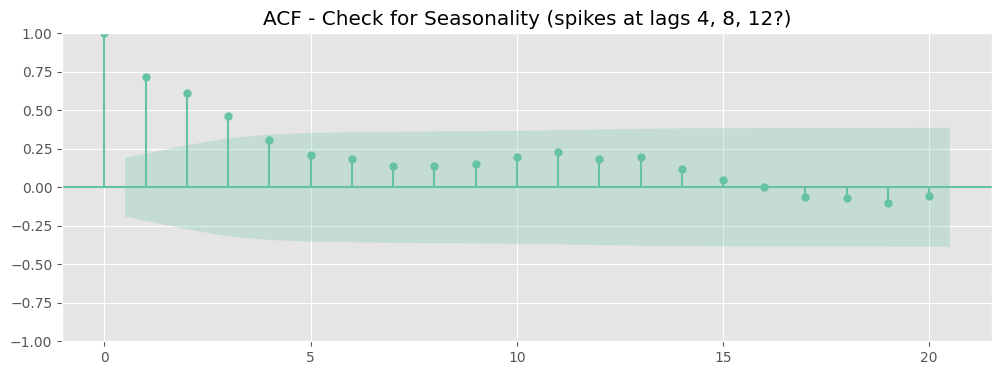


Do you see seasonal spikes at lags 4, 8, or 12? (y/n): y
 Using SARIMA with seasonal order: (1, 0, 1, 4)


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(model_series, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - for MA(q) selection', fontweight='bold')

plot_pacf(model_series, lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - for AR(p) selection', fontweight='bold')

plt.tight_layout()
plt.savefig('part2_acf_pacf.png', dpi=150)
plt.show()

print("\n ACF/PACF Interpretation Guide:")
print("   • If PACF cuts off after lag p → AR(p)")
print("   • If ACF cuts off after lag q → MA(q)")
print("   • If both decay slowly → need more differencing")
print("   • Spikes at lag 4 suggest monthly patterns")

# Based on visual inspection, select orders
# You may need to adjust these based on your actual plots
p = 1  # From PACF - where it cuts off
d = transformations['diff']  # From stationarity testing
q = 1  # From ACF - where it cuts off

order = (p, d, q)
print(f"\n Selected ARIMA order: {order}")

# Check for seasonality (monthly patterns in weekly data = period 4)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(model_series, lags=20, ax=ax)
ax.set_title('ACF - Check for Seasonality (spikes at lags 4, 8, 12?)')
plt.show()

use_sarima = input("\nDo you see seasonal spikes at lags 4, 8, or 12? (y/n): ").lower() == 'y'

if use_sarima:
    seasonal_order = (1, 0, 1, 4)  # (P, D, Q, period) for monthly patterns in weekly data
    print(f" Using SARIMA with seasonal order: {seasonal_order}")
else:
    seasonal_order = None


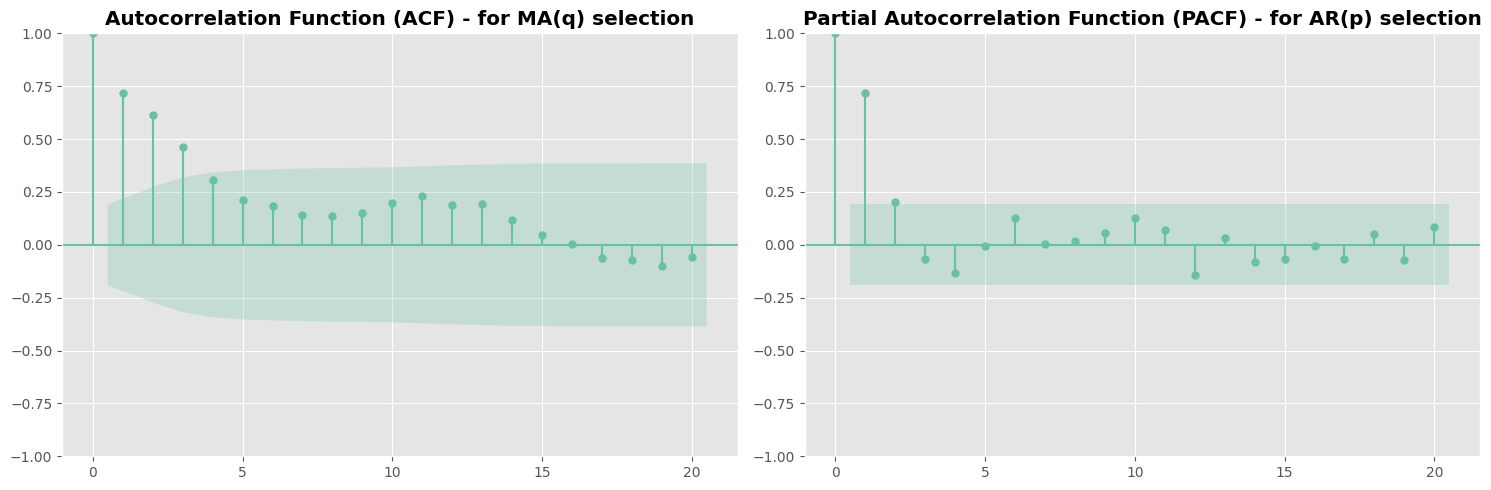


 ACF/PACF Interpretation Guide:
   • If PACF cuts off after lag p → AR(p)
   • If ACF cuts off after lag q → MA(q)
   • If both decay slowly → need more differencing
   • Spikes at lag 4 suggest monthly patterns

 Selected ARIMA order: (1, 0, 1)


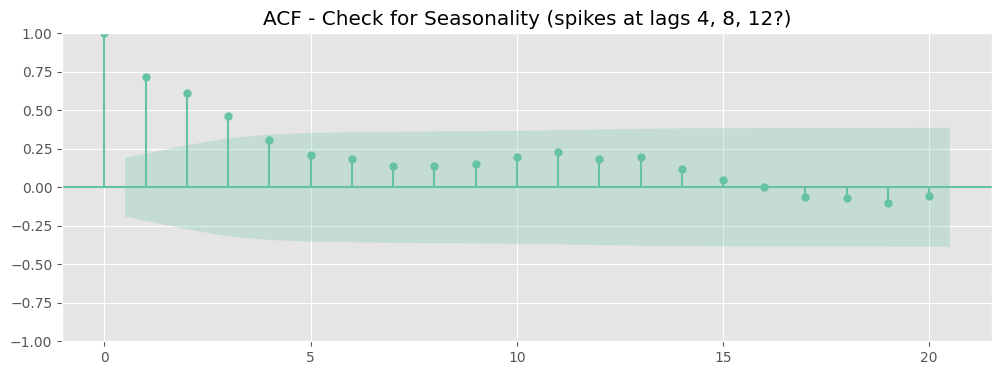


Do you see seasonal spikes at lags 4, 8, or 12? (y/n): n


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(model_series, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - for MA(q) selection', fontweight='bold')

plot_pacf(model_series, lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - for AR(p) selection', fontweight='bold')

plt.tight_layout()
plt.savefig('part2_acf_pacf.png', dpi=150)
plt.show()

print("\n ACF/PACF Interpretation Guide:")
print("   • If PACF cuts off after lag p → AR(p)")
print("   • If ACF cuts off after lag q → MA(q)")
print("   • If both decay slowly → need more differencing")
print("   • Spikes at lag 4 suggest monthly patterns")

# Based on visual inspection, select orders
# You may need to adjust these based on your actual plots
p = 1  # From PACF - where it cuts off
d = transformations['diff']  # From stationarity testing
q = 1  # From ACF - where it cuts off

order = (p, d, q)
print(f"\n Selected ARIMA order: {order}")

# Check for seasonality (monthly patterns in weekly data = period 4)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(model_series, lags=20, ax=ax)
ax.set_title('ACF - Check for Seasonality (spikes at lags 4, 8, 12?)')
plt.show()

use_sarima = input("\nDo you see seasonal spikes at lags 4, 8, or 12? (y/n): ").lower() == 'y'

if use_sarima:
    seasonal_order = (1, 0, 1, 4)  # (P, D, Q, period) for monthly patterns in weekly data
    print(f" Using SARIMA with seasonal order: {seasonal_order}")
else:
    seasonal_order = None


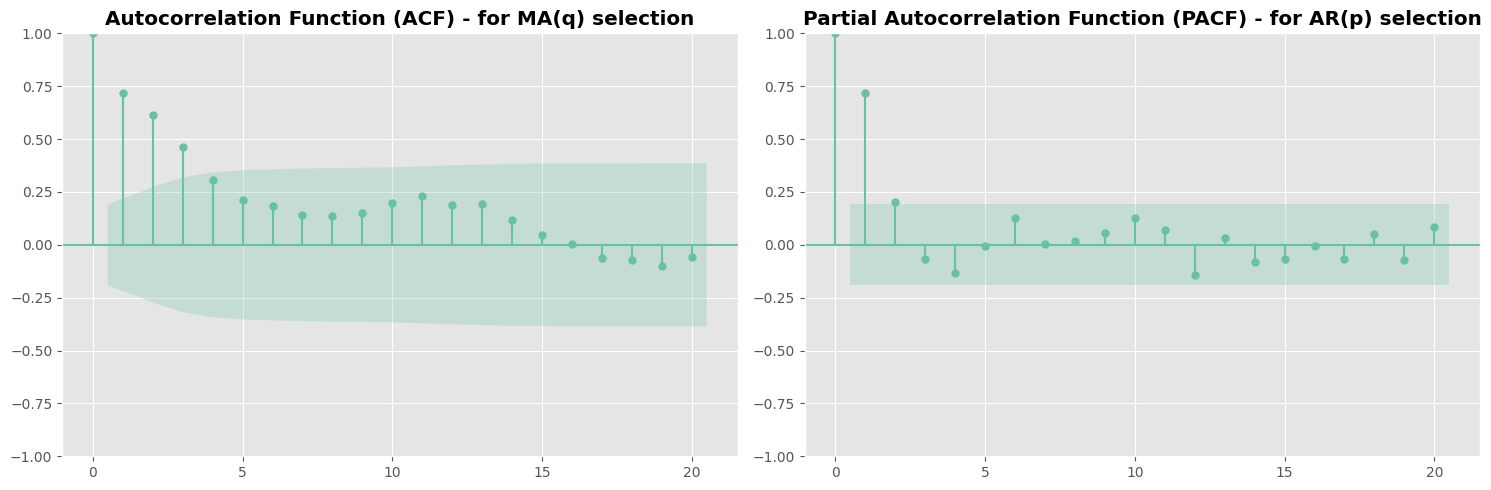


 ACF/PACF Interpretation Guide:
   • If PACF cuts off after lag p → AR(p)
   • If ACF cuts off after lag q → MA(q)
   • If both decay slowly → need more differencing
   • Spikes at lag 4 suggest monthly patterns

 Selected ARIMA order: (1, 0, 1)


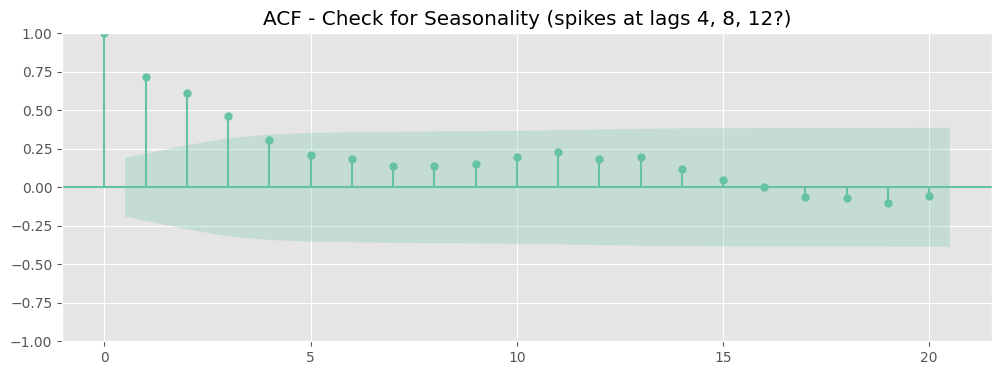


Do you see seasonal spikes at lags 4, 8, or 12? (y/n): y
 Using SARIMA with seasonal order: (1, 0, 1, 4)


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(model_series, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - for MA(q) selection', fontweight='bold')

plot_pacf(model_series, lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - for AR(p) selection', fontweight='bold')

plt.tight_layout()
plt.savefig('part2_acf_pacf.png', dpi=150)
plt.show()

print("\n ACF/PACF Interpretation Guide:")
print("   • If PACF cuts off after lag p → AR(p)")
print("   • If ACF cuts off after lag q → MA(q)")
print("   • If both decay slowly → need more differencing")
print("   • Spikes at lag 4 suggest monthly patterns")

# Based on visual inspection, select orders
# You may need to adjust these based on your actual plots
p = 1  # From PACF - where it cuts off
d = transformations['diff']  # From stationarity testing
q = 1  # From ACF - where it cuts off

order = (p, d, q)
print(f"\n Selected ARIMA order: {order}")

# Check for seasonality (monthly patterns in weekly data = period 4)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(model_series, lags=20, ax=ax)
ax.set_title('ACF - Check for Seasonality (spikes at lags 4, 8, 12?)')
plt.show()

use_sarima = input("\nDo you see seasonal spikes at lags 4, 8, or 12? (y/n): ").lower() == 'y'

if use_sarima:
    seasonal_order = (1, 0, 1, 4)  # (P, D, Q, period) for monthly patterns in weekly data
    print(f" Using SARIMA with seasonal order: {seasonal_order}")
else:
    seasonal_order = None


# ARIMA MODEL FITTING AND EVALUATION

In [58]:
print("\n" + "-"*60)
print("STEP 10: ARIMA MODEL FITTING AND EVALUATION")
print("-"*60)


------------------------------------------------------------
STEP 10: ARIMA MODEL FITTING AND EVALUATION
------------------------------------------------------------


In [60]:
# Split data (80% train, 20% test)
train_size = int(len(model_series) * 0.8)
train, test = model_series[:train_size], model_series[train_size:]

print(f"\n Train/Test Split:")
print(f"   • Training period: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} weeks)")
print(f"   • Testing period: {test.index[0].date()} to {test.index[-1].date()} ({len(test)} weeks)")


 Train/Test Split:
   • Training period: 2022-01-02 to 2023-08-06 (84 weeks)
   • Testing period: 2023-08-13 to 2023-12-31 (21 weeks)


In [61]:
# Fit model
if use_sarima:
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
else:
    model = ARIMA(train, order=order)

model_fit = model.fit(disp=False)
print(f"\n Model fitted successfully")
print(model_fit.summary().tables[1])  # Show coefficients

# Forecast on test period
test_forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)



 Model fitted successfully
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9920      0.019     52.417      0.000       0.955       1.029
ma.L1         -0.3730      0.112     -3.317      0.001      -0.593      -0.153
ar.S.L4        0.5874      0.294      1.995      0.046       0.010       1.164
ma.S.L4       -0.7369      0.243     -3.027      0.002      -1.214      -0.260
sigma2      4.507e+12   5.84e-14   7.72e+25      0.000    4.51e+12    4.51e+12


In [63]:
# Calculate metrics
if transformations['log']:
    # Convert back to original scale for metrics
    test_actual = np.exp(test) if transformations['log'] else test
    test_pred = np.exp(test_forecast) if transformations['log'] else test_forecast

    # If also differenced, need to reconstruct
    if transformations['diff'] == 1:
        # This is simplified - in practice you'd need to reverse the differencing
        print("\n Note: Metrics are on log-differenced scale due to transformations")
        mae = mean_absolute_error(test, test_forecast)
        rmse = np.sqrt(mean_squared_error(test, test_forecast))
        mape = np.mean(np.abs((test - test_forecast) / test)) * 100
    else:
        mae = mean_absolute_error(test_actual, test_pred)
        rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
        mape = np.mean(np.abs((test_actual - test_pred) / test_actual)) * 100
else:
    mae = mean_absolute_error(test, test_forecast)
    rmse = np.sqrt(mean_squared_error(test, test_forecast))
    mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print(f"\n Model Performance Metrics:")
print(f"   • MAE (Mean Absolute Error): ${mae:,.0f}" if not transformations['log'] else f"   • MAE: {mae:.4f}")
print(f"   • RMSE (Root Mean Square Error): ${rmse:,.0f}" if not transformations['log'] else f"   • RMSE: {rmse:.4f}")
print(f"   • MAPE (Mean Absolute Percentage Error): {mape:.2f}%")


 Model Performance Metrics:
   • MAE (Mean Absolute Error): $5,532,323
   • RMSE (Root Mean Square Error): $6,359,839
   • MAPE (Mean Absolute Percentage Error): 49.66%


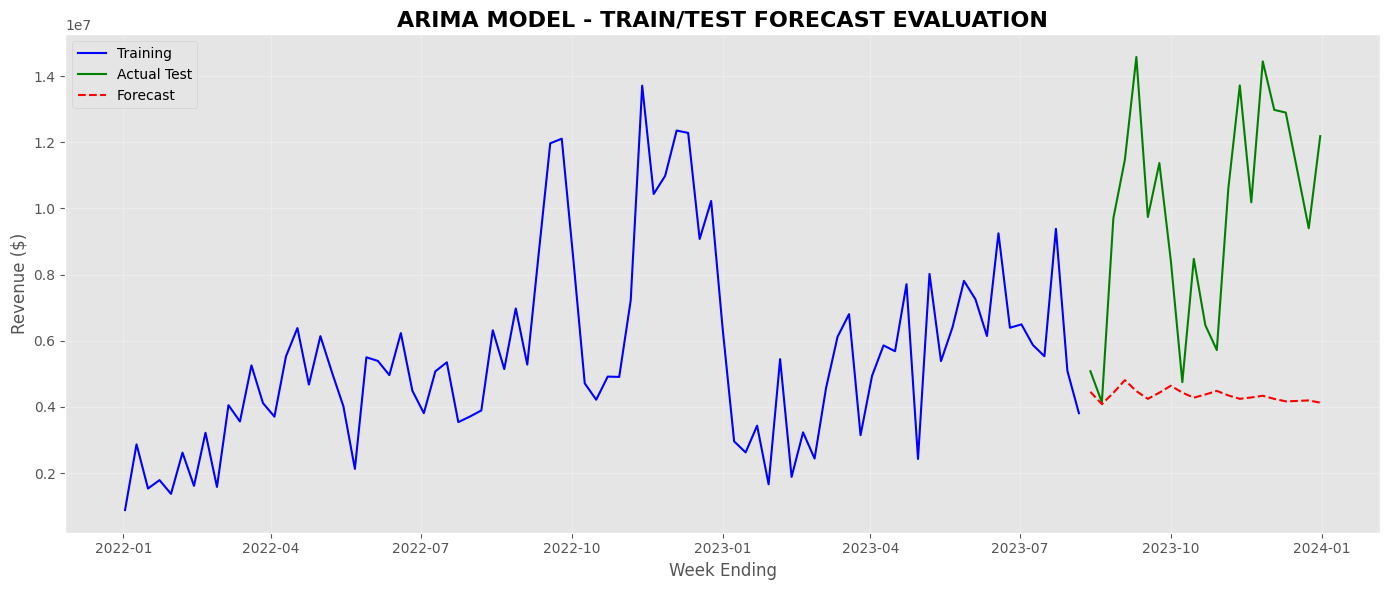

In [64]:
# Visualize forecast vs actual
plt.figure(figsize=(14, 6))

if transformations['log'] and transformations['diff'] == 0:
    plt.plot(train.index, np.exp(train), label='Training (actual)', color='blue')
    plt.plot(test.index, np.exp(test), label='Actual Test', color='green')
    plt.plot(test.index, np.exp(test_forecast), label='Forecast', color='red', linestyle='--')
    plt.ylabel('Revenue ($)')
else:
    plt.plot(train.index, train, label='Training', color='blue')
    plt.plot(test.index, test, label='Actual Test', color='green')
    plt.plot(test.index, test_forecast, label='Forecast', color='red', linestyle='--')
    plt.ylabel('Revenue' + (' (log scale)' if transformations['log'] else ' ($)'))

plt.title('ARIMA MODEL - TRAIN/TEST FORECAST EVALUATION', fontsize=16, fontweight='bold')
plt.xlabel('Week Ending')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_model_evaluation.png', dpi=150)
plt.show()


# FORECAST NEXT 4 WEEKS (FOR BUSINESS QUESTION)

In [65]:
print("\n" + "-"*60)
print("STEP 11: FORECAST NEXT 4 WEEKS - ANSWER TO BUSINESS QUESTION")
print("-"*60)


------------------------------------------------------------
STEP 11: FORECAST NEXT 4 WEEKS - ANSWER TO BUSINESS QUESTION
------------------------------------------------------------


In [66]:
# Forecast next 4 weeks
future_forecast = model_fit.forecast(steps=4)

# Create forecast dates
last_date = model_series.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=4, freq='W')

In [67]:
# Convert back to original scale if needed
if transformations['log']:
    if transformations['diff'] == 1:
        # Need to reconstruct the actual values
        # This is a simplified approach - for production, use proper inverse transformations
        last_actual = weekly_revenue['Weekly_Revenue'].iloc[-1]
        forecast_values = []
        cum_sum = 0
        for i, fc in enumerate(future_forecast):
            cum_sum += fc
            forecast_values.append(np.exp(np.log(last_actual) + cum_sum) if i == 0 else np.exp(np.log(last_actual) + cum_sum))
        forecast_values = np.array(forecast_values)
    else:
        # Just exponentiate
        forecast_values = np.exp(future_forecast)
else:
    forecast_values = future_forecast.values

In [69]:
# Create forecast dataframe for client
forecast_df = pd.DataFrame({
    'Week_Ending': forecast_dates.strftime('%Y-%m-%d'),
    'Forecasted_Revenue': [f"${x:,.0f}" for x in forecast_values],
    'Lower_Bound_80%': [f"${x - 1.28*rmse:,.0f}" for x in forecast_values],
    'Upper_Bound_80%': [f"${x + 1.28*rmse:,.0f}" for x in forecast_values],
    'Lower_Bound_95%': [f"${x - 1.96*rmse:,.0f}" for x in forecast_values],
    'Upper_Bound_95%': [f"${x + 1.96*rmse:,.0f}" for x in forecast_values]
})

print("\n" + "="*70)
print(" ANSWER TO BUSINESS QUESTION: 4-WEEK REVENUE FORECAST")
print("="*70)
print(forecast_df.to_string(index=False))


 ANSWER TO BUSINESS QUESTION: 4-WEEK REVENUE FORECAST
Week_Ending Forecasted_Revenue Lower_Bound_80% Upper_Bound_80% Lower_Bound_95% Upper_Bound_95%
 2024-01-07         $4,456,409     $-3,684,184     $12,597,003     $-8,008,874     $16,921,693
 2024-01-14         $4,083,483     $-4,057,110     $12,224,076     $-8,381,801     $16,548,767
 2024-01-21         $4,424,327     $-3,716,267     $12,564,920     $-8,040,957     $16,889,610
 2024-01-28         $4,808,983     $-3,331,610     $12,949,576     $-7,656,301     $17,274,267


In [73]:
# Total for the month
total_month = forecast_values.sum()
print(f"\n TOTAL PROJECTED TURNOVER FOR NEXT MONTH: ${total_month:,.0f}")




 TOTAL PROJECTED TURNOVER FOR NEXT MONTH: $17,773,202


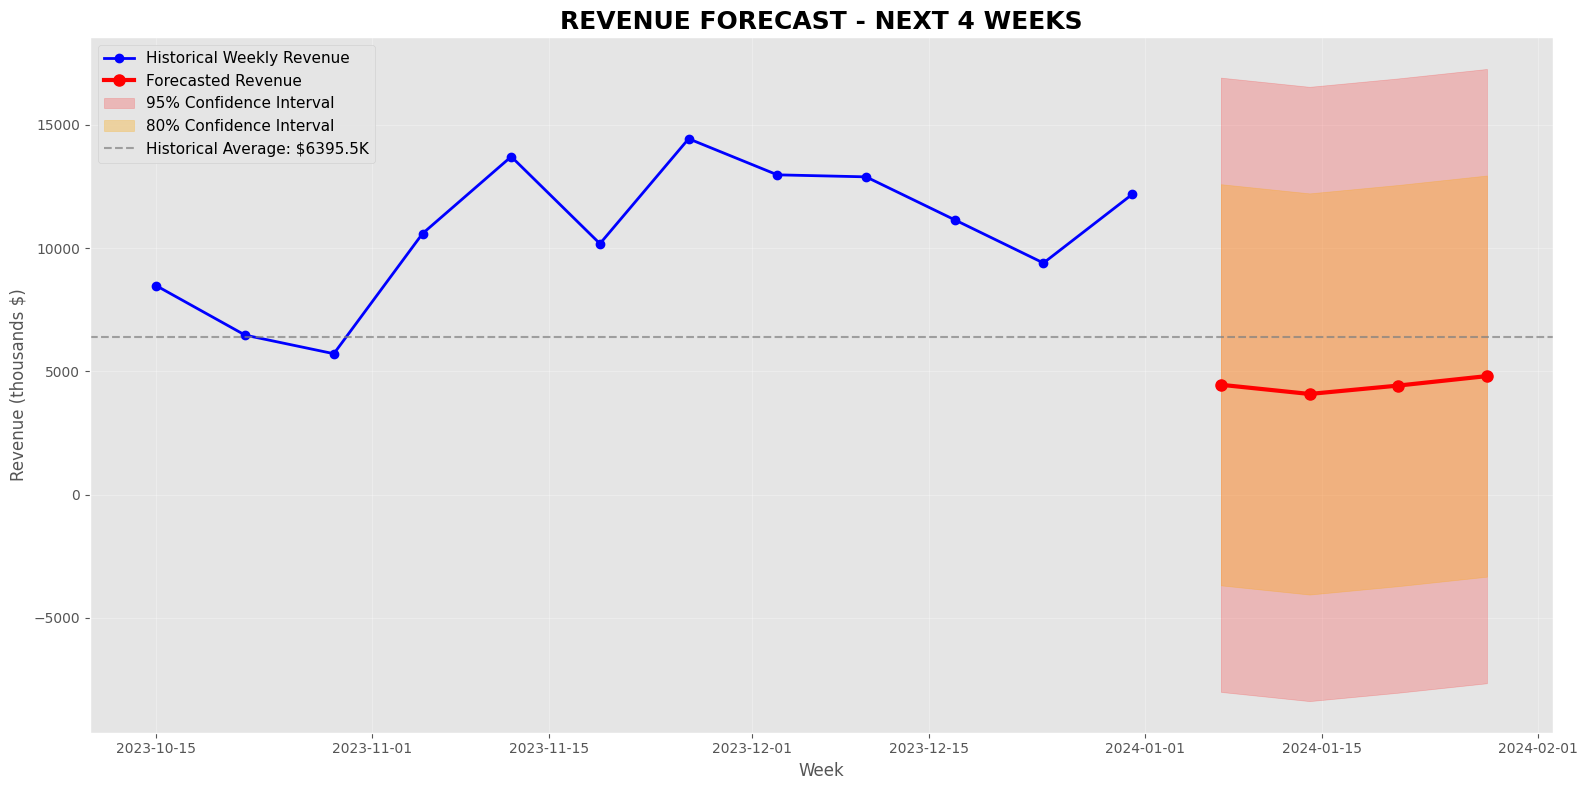

In [74]:
# Visualize forecast with historical data
plt.figure(figsize=(16, 8))

# Plot historical (last 12 weeks for context)
weeks_to_show = min(12, len(weekly_revenue))
historical = weekly_revenue.iloc[-weeks_to_show:]

plt.plot(historical.index, historical['Weekly_Revenue']/1000,
         'o-', color='blue', linewidth=2, markersize=6, label='Historical Weekly Revenue')

plt.plot(forecast_dates, forecast_values/1000,
         'o-', color='red', linewidth=3, markersize=8, label='Forecasted Revenue')


# Add confidence intervals
plt.fill_between(forecast_dates,
                 (forecast_values - 1.96*rmse)/1000,
                 (forecast_values + 1.96*rmse)/1000,
                 alpha=0.2, color='red', label='95% Confidence Interval')

plt.fill_between(forecast_dates,
                 (forecast_values - 1.28*rmse)/1000,
                 (forecast_values + 1.28*rmse)/1000,
                 alpha=0.3, color='orange', label='80% Confidence Interval')

plt.axhline(y=weekly_revenue['Weekly_Revenue'].mean()/1000,
            color='gray', linestyle='--', alpha=0.7, label=f"Historical Average: ${weekly_revenue['Weekly_Revenue'].mean()/1000:.1f}K")

plt.title('REVENUE FORECAST - NEXT 4 WEEKS', fontsize=18, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Revenue (thousands $)')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_final_forecast.png', dpi=150)
plt.show()


# RESIDUAL ANALYSIS (for model validation)

In [76]:
print("\n" + "-"*60)
print("STEP 12: RESIDUAL ANALYSIS - MODEL VALIDATION")
print("-"*60)


------------------------------------------------------------
STEP 12: RESIDUAL ANALYSIS - MODEL VALIDATION
------------------------------------------------------------


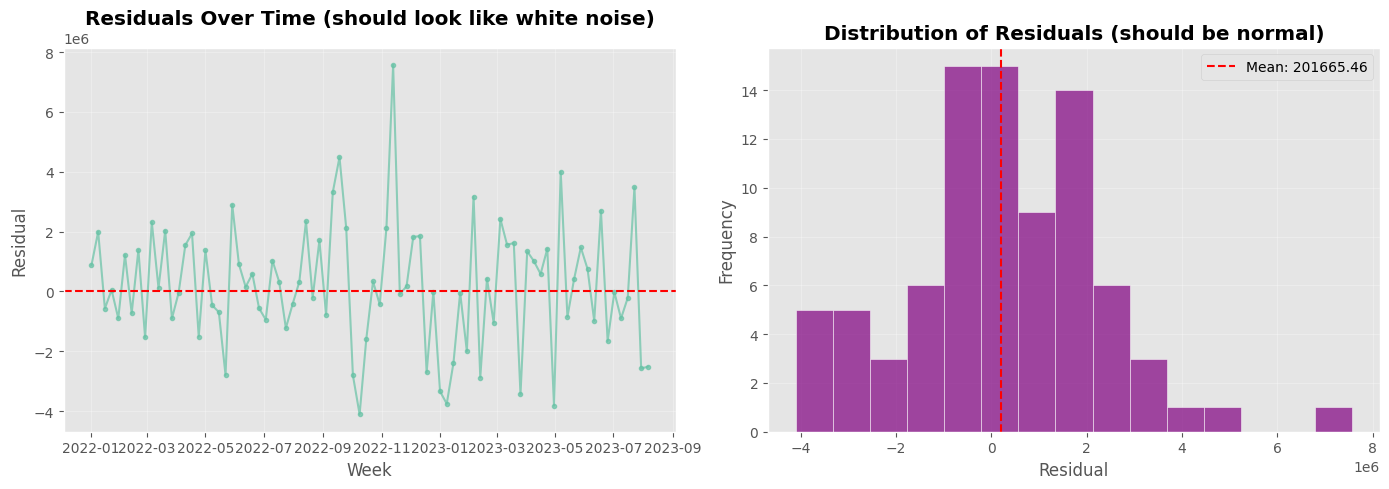


 Residual Summary:
   • Mean: 201665.4571 (should be close to 0)
   • Std Dev: 2063713.2452
   • Skewness: 0.3338 (should be near 0)


In [78]:
residuals = model_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals over time
axes[0].plot(residuals.index, residuals.values, 'o-', markersize=3, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals Over Time (should look like white noise)', fontweight='bold')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=15, edgecolor='white', alpha=0.7, color='purple')
axes[1].axvline(x=residuals.mean(), color='red', linestyle='--', label=f"Mean: {residuals.mean():.2f}")
axes[1].set_title('Distribution of Residuals (should be normal)', fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part2_residuals.png', dpi=150)
plt.show()

print(f"\n Residual Summary:")
print(f"   • Mean: {residuals.mean():.4f} (should be close to 0)")
print(f"   • Std Dev: {residuals.std():.4f}")
print(f"   • Skewness: {residuals.skew():.4f} (should be near 0)")

# REGIONAL ANALYSIS (for business implications)


In [79]:
# Top regions by revenue
region_revenue = df.groupby('Dealer_Region')['Price ($)'].agg(['sum', 'mean', 'count']).reset_index()
region_revenue.columns = ['Region', 'Total_Revenue', 'Avg_Price', 'Transaction_Count']
region_revenue = region_revenue.sort_values('Total_Revenue', ascending=False)

print("\n TOP 10 REGIONS BY TOTAL REVENUE:")
print(region_revenue.head(10).to_string(index=False))


 TOP 10 REGIONS BY TOTAL REVENUE:
    Region  Total_Revenue    Avg_Price  Transaction_Count
    Austin      117192531 28341.603628               4135
Janesville      106351234 27833.350955               3821
Scottsdale       95969374 27954.958928               3433
    Aurora       88687382 28334.626837               3130
Greenville       88149602 28180.819054               3128
     Pasco       88040714 28119.039923               3131
Middletown       87134628 27856.338875               3128


In [80]:
# Calculate each region's contribution
total_revenue_all = region_revenue['Total_Revenue'].sum()
region_revenue['Percent_of_Total'] = (region_revenue['Total_Revenue'] / total_revenue_all * 100).round(1)

print("\n REGIONAL REVENUE CONTRIBUTION:")
for i, row in region_revenue.head(5).iterrows():
    print(f"   • {row['Region']}: ${row['Total_Revenue']:,.0f} ({row['Percent_of_Total']}% of total)")


 REGIONAL REVENUE CONTRIBUTION:
   • Austin: $117,192,531 (17.5% of total)
   • Janesville: $106,351,234 (15.8% of total)
   • Scottsdale: $95,969,374 (14.3% of total)
   • Aurora: $88,687,382 (13.2% of total)
   • Greenville: $88,149,602 (13.1% of total)


#Filter regional data to see specific patterns

In [81]:
print("\n" + "-"*60)
print("STEP 14: REGIONAL PATTERN ANALYSIS")
print("-"*60)


------------------------------------------------------------
STEP 14: REGIONAL PATTERN ANALYSIS
------------------------------------------------------------


In [82]:
# Select top 3 regions for detailed analysis
top_regions = region_revenue.head(3)['Region'].tolist()
print(f"\n Analyzing patterns in top 3 regions: {top_regions}")



 Analyzing patterns in top 3 regions: ['Austin', 'Janesville', 'Scottsdale']


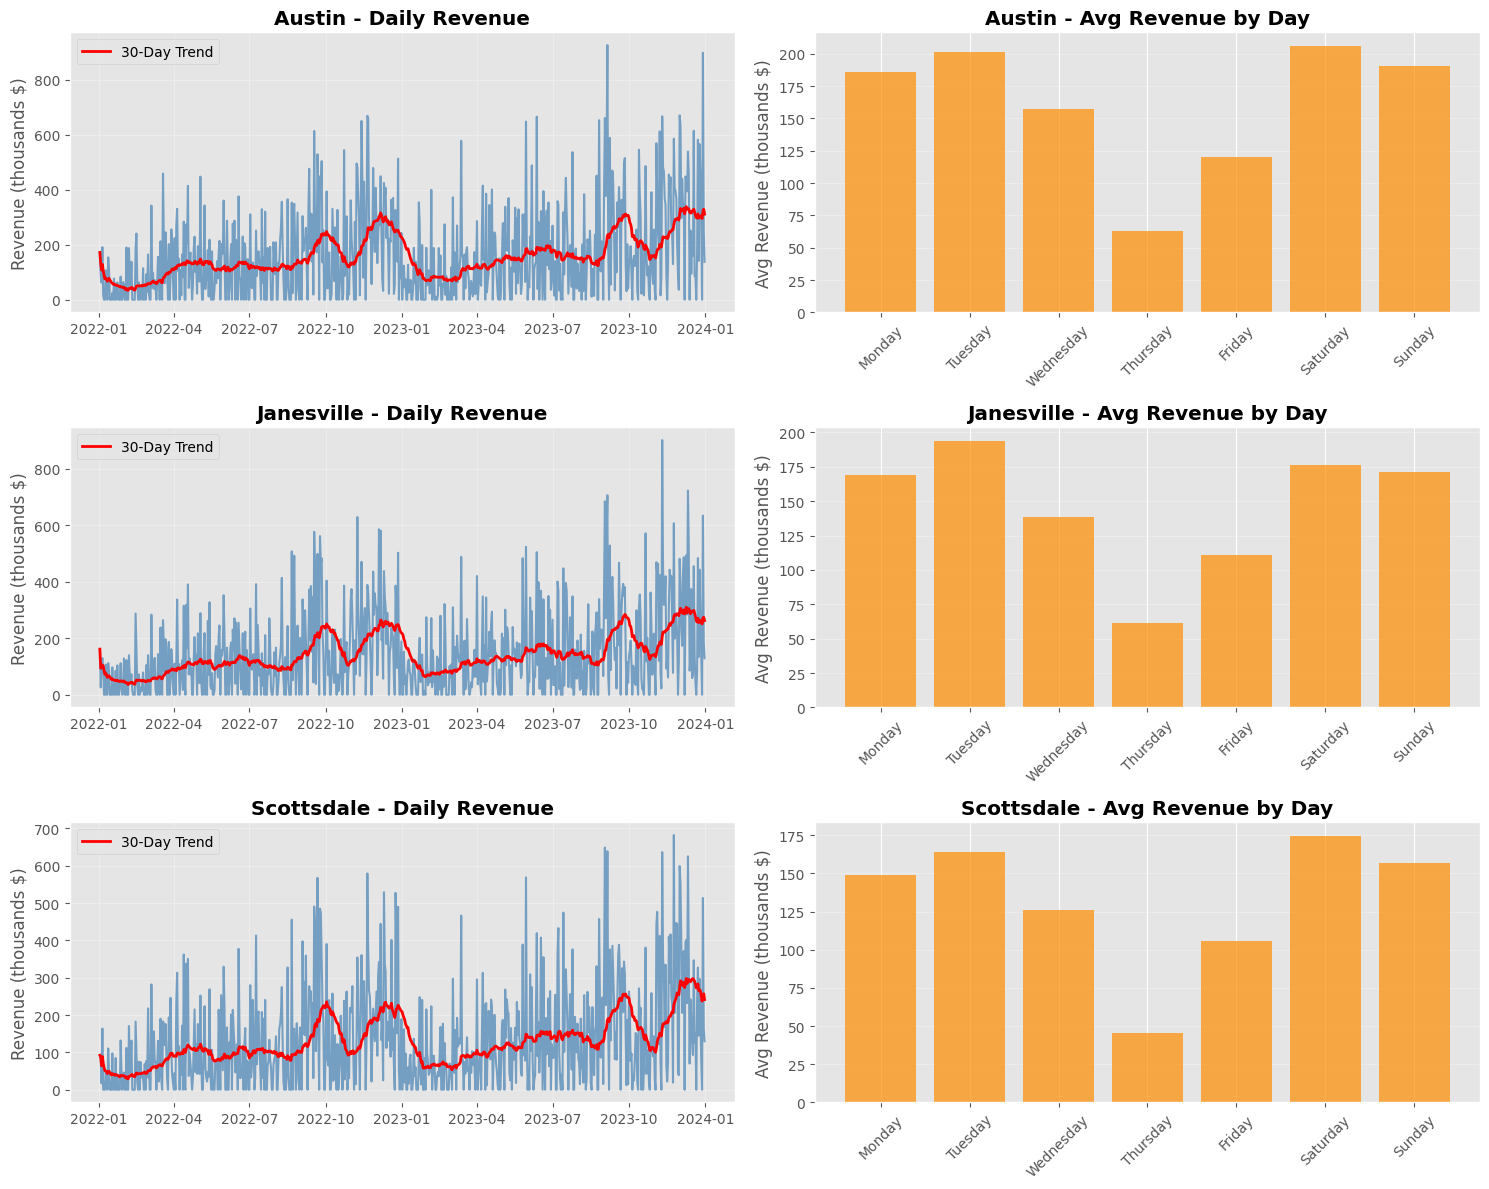

In [84]:
# Create regional daily data
regional_daily = {}

for region in top_regions:
    region_df = df[df['Dealer_Region'] == region].copy()

    # Daily revenue for region
    region_daily = region_df.resample('D', on='Date')['Price ($)'].sum()
    region_daily = region_daily.reindex(date_range, fill_value=0)

    regional_daily[region] = region_daily


# Plot regional patterns
fig, axes = plt.subplots(len(top_regions), 2, figsize=(15, 4*len(top_regions)))

for i, region in enumerate(top_regions):
    region_data = regional_daily[region]

    # Time series
    axes[i, 0].plot(region_data.index, region_data/1000, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{region} - Daily Revenue', fontweight='bold')
    axes[i, 0].set_ylabel('Revenue (thousands $)')
    axes[i, 0].grid(True, alpha=0.3)

    # 30-day rolling average
    rolling_30 = region_data.rolling(30, min_periods=1).mean()
    axes[i, 0].plot(region_data.index, rolling_30/1000, color='red', linewidth=2, label='30-Day Trend')
    axes[i, 0].legend()

    # Day of week pattern
    region_df_temp = pd.DataFrame({'revenue': region_data, 'day': region_data.index.day_name()})
    dow_pattern = region_df_temp.groupby('day')['revenue'].mean().reindex(day_order) / 1000

    axes[i, 1].bar(day_order, dow_pattern.values, color='darkorange', alpha=0.7)
    axes[i, 1].set_title(f'{region} - Avg Revenue by Day', fontweight='bold')
    axes[i, 1].set_ylabel('Avg Revenue (thousands $)')
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('part2_regional_patterns.png', dpi=150)
plt.show()


# Business implications of regional patterns

In [85]:
print("\n" + "-"*60)
print("STEP 15: BUSINESS IMPLICATIONS - REGIONAL PATTERNS")
print("-"*60)


------------------------------------------------------------
STEP 15: BUSINESS IMPLICATIONS - REGIONAL PATTERNS
------------------------------------------------------------


In [86]:
print("\n REGIONAL BUSINESS INSIGHTS:")
print("-"*40)

for region in top_regions:
    region_data = regional_daily[region]
    region_df_subset = df[df['Dealer_Region'] == region]

    # Key metrics
    total_rev = region_data.sum()
    avg_daily = region_data.mean()
    avg_price = region_df_subset['Price ($)'].mean()
    peak_day = region_data.groupby(region_data.index.day_name()).mean().idxmax()
    zero_days = (region_data == 0).sum()

    print(f"\n    {region}:")
    print(f"      • Total revenue: ${total_rev:,.0f}")
    print(f"      • Average daily: ${avg_daily:,.0f}")
    print(f"      • Average transaction: ${avg_price:,.0f}")
    print(f"      • Peak day: {peak_day}")
    print(f"      • Days with no sales: {zero_days}")

    # Business implications
    if avg_price > 50000:
        print(f"      •  IMPLICATION: Premium market - focus on luxury inventory, personalized service")
    elif avg_price < 25000:
        print(f"      •  IMPLICATION: Value market - emphasize affordability, volume-based promotions")

    if zero_days > len(region_data) * 0.1:  # More than 10% zero days
        print(f"      •  IMPLICATION: Inconsistent operations - review staffing/supply")

    # Weekend vs weekday pattern
    weekend_rev = region_data[region_data.index.dayofweek.isin([5,6])].mean()
    weekday_rev = region_data[region_data.index.dayofweek.isin([0,1,2,3,4])].mean()

    if weekend_rev > weekday_rev * 1.2:
        print(f"      •  IMPLICATION: Weekend-focused - allocate more staff/promotions on weekends")
    elif weekday_rev > weekend_rev * 1.2:
        print(f"      •  IMPLICATION: Weekday-focused - target business customers, B2B marketing")



 REGIONAL BUSINESS INSIGHTS:
----------------------------------------

    Austin:
      • Total revenue: $117,192,531
      • Average daily: $160,758
      • Average transaction: $28,342
      • Peak day: Saturday
      • Days with no sales: 150
      •  IMPLICATION: Inconsistent operations - review staffing/supply
      •  IMPLICATION: Weekend-focused - allocate more staff/promotions on weekends

    Janesville:
      • Total revenue: $106,351,234
      • Average daily: $145,886
      • Average transaction: $27,833
      • Peak day: Tuesday
      • Days with no sales: 153
      •  IMPLICATION: Inconsistent operations - review staffing/supply
      •  IMPLICATION: Weekend-focused - allocate more staff/promotions on weekends

    Scottsdale:
      • Total revenue: $95,969,374
      • Average daily: $131,645
      • Average transaction: $27,955
      • Peak day: Saturday
      • Days with no sales: 150
      •  IMPLICATION: Inconsistent operations - review staffing/supply
      •  IMPL

# FINAL CLIENT REPORT - EXECUTIVE SUMMARY

In [87]:
print("\n" + "="*80)
print("EXECUTIVE SUMMARY - FINANCIAL REVENUE & CASH FLOW PLANNING")
print("="*80)


EXECUTIVE SUMMARY - FINANCIAL REVENUE & CASH FLOW PLANNING


In [89]:
print(f"""
 BUSINESS QUESTION ANSWERED:
   What is the projected turnover for the upcoming month?

 FORECAST RESULT:
   • Total projected revenue for next 4 weeks: ${total_month:,.0f}
   • Confidence range (95%): ${(forecast_values - 1.96*rmse).sum():,.0f} - ${(forecast_values + 1.96*rmse).sum():,.0f}
   • Weekly breakdown: {', '.join([f"${x:,.0f}" for x in forecast_values])}

 KEY PATTERNS IDENTIFIED:
   • Overall business averages ${daily_data['total_revenue'].mean()/1000:.1f}K daily revenue
   • Best revenue day: {dow_avg.idxmax()} (${dow_avg.max():.1f}K average)
   • 30-day trend: {'INCREASING' if rolling_data['revenue_ma_30'].iloc[-1] > rolling_data['revenue_ma_30'].iloc[-30] else 'DECREASING'}
   • 90-day trend: {'INCREASING' if rolling_data['revenue_ma_90'].iloc[-1] > rolling_data['revenue_ma_90'].iloc[-90] else 'DECREASING'}

 REGIONAL HIGHLIGHTS:
   • Top region: {top_regions[0]} (${region_revenue.iloc[0]['Total_Revenue']:,.0f} total)
   • Top 3 regions account for {region_revenue.head(3)['Percent_of_Total'].sum():.1f}% of total revenue
   • Regional patterns show different peak days - customize marketing accordingly

 CASH FLOW PLANNING RECOMMENDATIONS:
   1. EXPECTED INFLOW: Schedule supplier payments of up to 40% of projected revenue
   2. MARKETING BUDGET: Allocate 15-20% of projected revenue for next month's campaigns
   3. CAPITAL EXPENDITURE: Plan major purchases for weeks with highest forecast
   4. RISK MANAGEMENT: Maintain cash reserve of ${(forecast_values - 1.96*rmse).sum():,.0f} (lower bound)
""")

# Save all results for client
forecast_df.to_csv('part2_revenue_forecast.csv', index=False)
region_revenue.to_csv('part2_regional_analysis.csv', index=False)
daily_data.to_csv('part2_daily_data.csv')

print("\n All results saved to CSV files:")
print("   • part2_revenue_forecast.csv - 4-week forecast for client")
print("   • part2_regional_analysis.csv - Regional breakdown")
print("   • part2_daily_data.csv - Daily aggregates")
print("\n Visualizations saved:")
print("   • part2_pattern_analysis.png")
print("   • part2_multiple_windows.png")
print("   • part2_weekly_revenue.png")
print("   • part2_stationarity.png")
print("   • part2_acf_pacf.png")
print("   • part2_model_evaluation.png")
print("   • part2_final_forecast.png")
print("   • part2_residuals.png")
print("   • part2_regional_patterns.png")

print("\n" + "="*80)
print("PART 2 COMPLETE - READY FOR PRESENTATION")
print("="*80)


 BUSINESS QUESTION ANSWERED:
   What is the projected turnover for the upcoming month?

 FORECAST RESULT:
   • Total projected revenue for next 4 weeks: $17,773,202
   • Confidence range (95%): $-32,087,932 - $67,634,336
   • Weekly breakdown: $4,456,409, $4,083,483, $4,424,327, $4,808,983

 KEY PATTERNS IDENTIFIED:
   • Overall business averages $921.2K daily revenue
   • Best revenue day: Tuesday ($1185.3K average)
   • 30-day trend: DECREASING
   • 90-day trend: INCREASING

 REGIONAL HIGHLIGHTS:
   • Top region: Austin ($117,192,531 total)
   • Top 3 regions account for 47.6% of total revenue
   • Regional patterns show different peak days - customize marketing accordingly

 CASH FLOW PLANNING RECOMMENDATIONS:
   1. EXPECTED INFLOW: Schedule supplier payments of up to 40% of projected revenue
   2. MARKETING BUDGET: Allocate 15-20% of projected revenue for next month's campaigns
   3. CAPITAL EXPENDITURE: Plan major purchases for weeks with highest forecast
   4. RISK MANAGEMENT: M